## final project


final project

problem statement-predicting House prices(California)
>On real world dataset

<img scr="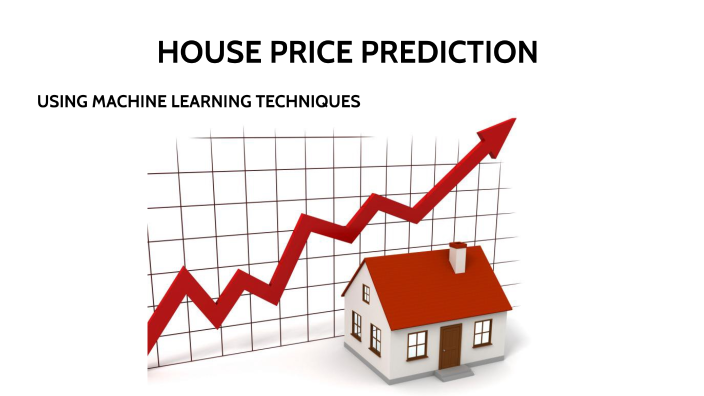">

### California House Price Prediction Project

### Objective
> The objective of this project is to build a multiple linear regression model that predicts the median house value in California districts based on various features like median income, housing median age, and average room countsect...


#### Machine Learning Pipeline

* Data Collection and Import
* Exploratory Data Analysis & Data Cleaning (Handling Nulls and Duplicates)
* Feature Selection & Data Splitting
* Feature Scaling (Standardization)
* Model Building & Training
* Model Evaluation

###### Step 1: Data Collection and Import
###### Load the dataset from a URL or local file path

>> Import requuired libraries

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
data_url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"


In [ ]:
df = pd.read_csv(data_url)

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


>> In the feature called "total_bedrooms" we have null values so we nned fix it (by mean/median)

In [ ]:
# duplicated ..

duplicates = df.duplicated().sum()
print("Number of duplicate rows :"+str(duplicates))

Number of duplicate rows :0


In [ ]:
df["total_bedrooms"].isnull().sum()

np.int64(207)

In [ ]:
# Handle missing values: Fill missing 'total_bedrooms' with the median of that column
median_bedrooms = df["total_bedrooms"].median()
df["total_bedrooms"].fillna(median_bedrooms,inplace=True)

/tmp/ipykernel_13551/115780233.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bedrooms"].fillna(median_bedrooms,inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [ ]:
### Enhancing the Model: One-Hot Encoding and Feature Engineering
# Apply one-hot encoding to 'ocean_proximity'
df_encoded =  pd.get_dummies(df, columns=['ocean_proximity'])
df_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


##### feature engineering...

>creating new features (based on
other features(columns,input,vectors)







In [ ]:
# Create new features
df_encoded['rooms_per_household'] = df_encoded['total_rooms'] / df_encoded['households']
df_encoded['bedrooms_per_room'] = df_encoded['total_bedrooms'] / df_encoded['total_rooms']
df_encoded['population_per_household'] = df_encoded['population'] / df_encoded['households']

df_encoded.head()



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False,6.281853,0.172096,2.181467


### vertical split (i/p o/p)

In [ ]:
x=df_encoded.drop(columns = "median_house_value")

In [ ]:
x.columns


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN', 'rooms_per_household',
       'bedrooms_per_room', 'population_per_household'],
      dtype='object')

In [ ]:
Y=df_encoded["median_house_value"] #o/p

##### Horizontal spliting(train,test)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Split the data into training (80%) and testing (20%) sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    x,Y, test_size=0.2, random_state=42
)

In [ ]:
X_train_new

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,False,False,False,False,True,5.017657,0.200576,3.691814
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,False,False,False,False,True,4.473545,0.232703,1.738095
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,False,False,False,False,True,5.645833,0.174486,2.723214
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,False,False,False,False,True,4.002817,0.258269,3.994366
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,False,True,False,False,False,6.268421,0.180940,2.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,True,False,False,False,False,6.129032,0.151128,3.032258
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,False,True,False,False,False,6.868597,0.184825,3.904232
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,True,False,False,False,False,3.986717,0.270823,3.332068
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,True,False,False,False,False,6.395349,0.166993,3.178891


standarized

In [ ]:
from sklearn.preprocessing import StandardScaler
# Initialize the StandardScaler
scaler_new = StandardScaler()

# Fit and transform the training features
X_train_scaled_new = scaler_new.fit_transform(X_train_new) ## mean and sd

# Transform the testing features using the training set scaler
X_test_scaled_new = scaler_new.transform(X_test_new) # mean and sd

In [ ]:
###3 use regession model
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [ ]:
lr.fit(X_train_scaled_new,y_train_new)

LinearRegression()

In [ ]:
y_predict=lr.predict(X_test_scaled_new)

In [ ]:
### model evaluation
from sklearn.metrics import r2_score,root_mean_squared_error
print("RMSE:",root_mean_squared_error(y_test_new,y_predict))
print("R2_Score:",r2_score(y_test_new,y_predict))


RMSE: 72668.53837868226
R2_Score: 0.5970176824350761


#### random forest

## Random Forest Regressor

> Ensemble learning algorithm

> models used = Decision Tree

> for classification - majority  

> for regression - average


<img src="https://www.slideteam.net/media/catalog/product/cache/1280x720/f/r/framework_of_random_forest_regression_algorithm_ppt_sample_slide01.jpg" >

In [ ]:
## Change the model to RandomForesetRegression
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled_new,y_train_new)
rfpredict = rf.predict(X_test_scaled_new)
print("RMSE:",root_mean_squared_error(y_test_new,rfpredict))
print("R2_Score:",r2_score(y_test_new,rfpredict))


RMSE: 50368.15768695257
R2_Score: 0.8064000361029778


>>>> Random forest has hugher performance compare to linear Regression

In [ ]:
import pickle

pickle.dump(rf,open("rfmodel.pkl","wb"))